In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("Thyroid_Diff.csv")
df

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [3]:
df.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

In [5]:
df.nunique()

Age                     65
Gender                   2
Smoking                  2
Hx Smoking               2
Hx Radiothreapy          2
Thyroid Function         5
Physical Examination     5
Adenopathy               6
Pathology                4
Focality                 2
Risk                     3
T                        7
N                        3
M                        2
Stage                    5
Response                 4
Recurred                 2
dtype: int64

In [6]:
cat_features = list(df.columns)
cat_features.remove('Age')
cat_features.remove('Recurred')
target= 'Recurred'
num_features = ['Age']

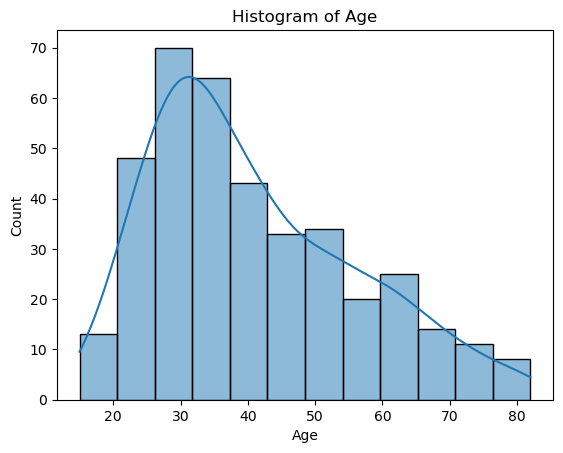

In [7]:
sns.histplot(data= df , x='Age', kde=True)
plt.title('Histogram of Age')
plt.show()

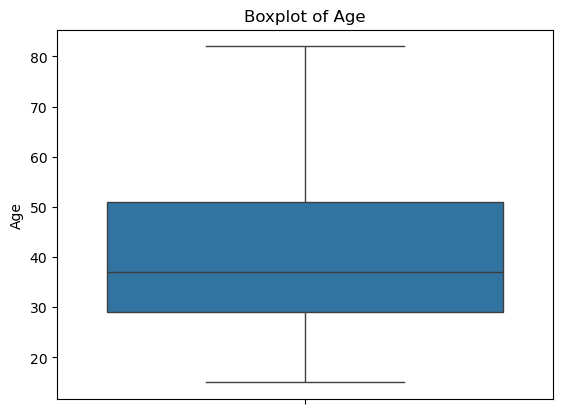

In [8]:
# Boxplot for outlier detection
sns.boxplot(y=df['Age'])
plt.title("Boxplot of Age")
plt.show()

In [9]:
target = 'Recurred'

In [10]:
# Inferential testing for the numeric features 
import pandas as pd
from scipy import stats

def test_t (feature, target):


    group1 = df[df[target] == 'No'][feature]
    group2 = df[df[target] == 'Yes'][feature]


    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)

    return t_stat, p_val

col = 'Age'
_, p_val = test_t(col , target)
print("-"*60)
print (f"Testing the {col} ")
print(f"P- val : {p_val}")
if p_val < 0.05:
    print("Significant difference between groups.")
else:
    print("No significant difference between groups.")
print("All the numeric features are significant for model building ")

------------------------------------------------------------
Testing the Age 
P- val : 1.2330484085307432e-05
Significant difference between groups.
All the numeric features are significant for model building 


In [11]:
sig_num_feat = ['Age']

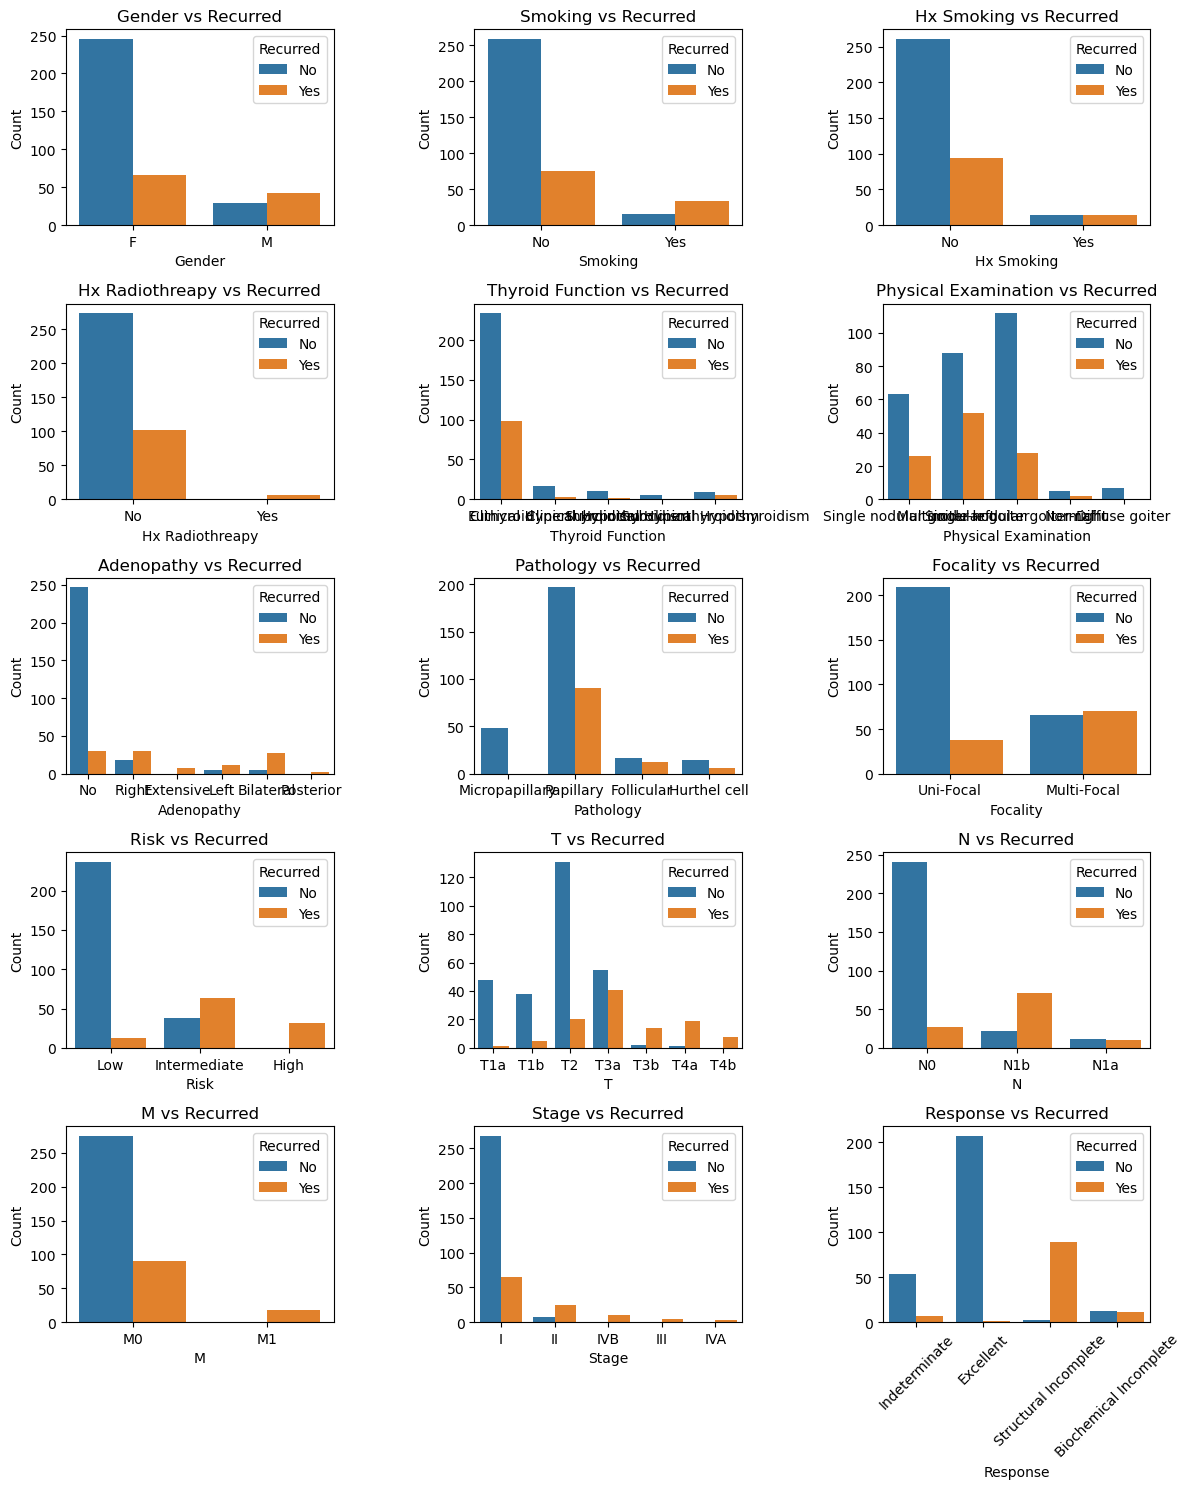

In [12]:
fig, axes = plt.subplots(5, 3, figsize=(12, 15))
axes = axes.flatten()

for col, ax in zip(cat_features, axes):
    sns.countplot(x=col, hue=target, data=df, ax=ax)
    ax.set_title(f"{col} vs {target}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
from scipy.stats import chi2_contingency

def chi_square_test(df, col1, col2):
    # Build contingency table
    contingency_table = pd.crosstab(df[col1], df[col2])
    
    # Run Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    result = {
        "chi2_statistic": np.round(chi2,3),
        "p_value": np.round(p,3),
        # "degrees_of_freedom": dof,
        # "expected_freq": expected,
        "interpretation": "Significant association"
                         if p < 0.05 else "No significant association"
    }
    return result



In [14]:
for col in cat_features:
    res = chi_square_test(df, col, target)
    print("="*60)
    print(col)
    print(res)

Gender
{'chi2_statistic': np.float64(39.397), 'p_value': np.float64(0.0), 'interpretation': 'Significant association'}
Smoking
{'chi2_statistic': np.float64(40.344), 'p_value': np.float64(0.0), 'interpretation': 'Significant association'}
Hx Smoking
{'chi2_statistic': np.float64(5.977), 'p_value': np.float64(0.014), 'interpretation': 'Significant association'}
Hx Radiothreapy
{'chi2_statistic': np.float64(8.936), 'p_value': np.float64(0.003), 'interpretation': 'Significant association'}
Thyroid Function
{'chi2_statistic': np.float64(5.149), 'p_value': np.float64(0.272), 'interpretation': 'No significant association'}
Physical Examination
{'chi2_statistic': np.float64(12.974), 'p_value': np.float64(0.011), 'interpretation': 'Significant association'}
Adenopathy
{'chi2_statistic': np.float64(157.044), 'p_value': np.float64(0.0), 'interpretation': 'Significant association'}
Pathology
{'chi2_statistic': np.float64(23.27), 'p_value': np.float64(0.0), 'interpretation': 'Significant associati

# Interpretation 
- All the categorical features are associated with target variable except Tyroid Function

In [15]:
sig_cat_feat = cat_features.copy()
sig_cat_feat.remove('Thyroid Function')
sig_cat_feat

['Gender',
 'Smoking',
 'Hx Smoking',
 'Hx Radiothreapy',
 'Physical Examination',
 'Adenopathy',
 'Pathology',
 'Focality',
 'Risk',
 'T',
 'N',
 'M',
 'Stage',
 'Response']

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Encoding the 

In [17]:
sig_feat = sig_num_feat+sig_cat_feat


In [18]:
for feat in sig_cat_feat:
    print(f" {feat}\n\n{df[feat].unique()}\n{'-'*80}")

 Gender

['F' 'M']
--------------------------------------------------------------------------------
 Smoking

['No' 'Yes']
--------------------------------------------------------------------------------
 Hx Smoking

['No' 'Yes']
--------------------------------------------------------------------------------
 Hx Radiothreapy

['No' 'Yes']
--------------------------------------------------------------------------------
 Physical Examination

['Single nodular goiter-left' 'Multinodular goiter'
 'Single nodular goiter-right' 'Normal' 'Diffuse goiter']
--------------------------------------------------------------------------------
 Adenopathy

['No' 'Right' 'Extensive' 'Left' 'Bilateral' 'Posterior']
--------------------------------------------------------------------------------
 Pathology

['Micropapillary' 'Papillary' 'Follicular' 'Hurthel cell']
--------------------------------------------------------------------------------
 Focality

['Uni-Focal' 'Multi-Focal']
--------------------

In [19]:
# mappings 
bin_map = { 'Yes':1 , 'No': 0}

#Risk ['Low' 'Intermediate' 'High']
risk_map = {'Low' : 0, 'Intermediate':1, 'High' : 2}

# Stage 
stage_map = {'I' : 0, 'II' : 1, 'III' : 2, 'IVA' : 3, 'IVB' : 4}

# T map 
T_map = {'T1a':0 , 'T1b': 1, 'T2' : 2, 'T3a' : 3, 'T3b' : 4, 'T4a' :5, 'T4b' : 6}

# N map

N_map = {'N0' : 0, 'N1b' : 1, 'N1a' : 2}

# M map
M_map = {'M0' : 0, 'M1' : 1}


In [20]:
ordinal_mappings = {
    "Risk": {"Low":1, "Intermediate":2, "High":3},
    "T": {"T1a":1, "T1b":2, "T2":3, "T3a":4, "T3b":5, "T4a":6, "T4b":7},
    "N": {"N0":0, "N1a":1, "N1b":2},
    "M": {"M0":0, "M1":1},
    "Stage": {"I":1, "II":2, "III":3, "IVA":4, "IVB":5},
    "Response": {
        "Excellent":1,
        "Indeterminate":2,
        "Biochemical Incomplete":3,
        "Structural Incomplete":4
    }
}

nominal_features = [
    "Gender", "Smoking", "Hx Smoking", "Hx Radiothreapy",
    "Physical Examination", "Adenopathy", "Pathology", "Focality", "Recurred"
]

In [21]:
for feature, mapping in ordinal_mappings.items():
    df[feature] = df[feature].map(mapping)
df

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,1,1,0,0,1,2,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,1,1,0,0,1,1,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,1,1,0,0,1,1,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,1,1,0,0,1,1,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,1,1,0,0,1,1,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,3,7,2,1,5,3,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,3,7,2,1,5,4,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,3,7,2,1,5,4,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,3,7,2,0,4,4,Yes


In [22]:
risk = ordinal_mappings['Risk']

In [23]:
df

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,1,1,0,0,1,2,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,1,1,0,0,1,1,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,1,1,0,0,1,1,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,1,1,0,0,1,1,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,1,1,0,0,1,1,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,3,7,2,1,5,3,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,3,7,2,1,5,4,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,3,7,2,1,5,4,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,3,7,2,0,4,4,Yes
